 # Scenario-1 Detection vs Forecast – XGBoost Model Comparison (Human-Readable Features)



 This notebook compares two XGBoost models trained on CERT r5.2 for Scenario 1:



 - **Detection model**: predicts whether a 14-day window overlaps an exfiltration range.

 - **Forecast model**: predicts whether a 14-day window is within a pre-exfil horizon.



 Both models reuse the **same user-level train/val/test split**; only the label definitions differ.



 Goals:



 - Recompute metrics (AUC / Average Precision) for both models.

 - Inspect score distributions.

 - Inspect **feature importance with actual feature names** instead of `f123`.

 - Aggregate importance at the **base feature** level (across all 14 days).

 - Optional SHAP explanations (if `shap` is installed).

 - Leaf index fingerprints and hyperparameter audit.



 The point is to understand *how* the models are making decisions and where to push next ML-wise.

 ## 1. Imports and Path Setup

In [1]:
# %%
from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

# Try to import xgboost and shap
try:
    import xgboost as xgb
except ImportError:
    xgb = None
    print("WARNING: xgboost is not installed. Install it to run this notebook.")

try:
    import shap
except ImportError:
    shap = None
    print("INFO: shap is not installed. SHAP sections will be skipped.")

print("CWD:", Path.cwd())

# Resolve release from release.txt if present, otherwise default to r5.2
release_file = Path("release.txt")
if release_file.exists():
    REL = release_file.read_text().strip() or "r5.2"
else:
    REL = "r5.2"

print(f"Using CERT release: {REL}")


def find_root_for_release(rel: str) -> Path:
    """
    Find out/<REL> walking up from the current working directory.

    Handles running the notebook from:
      - repo root:            out/<REL>
      - notebooks/:          ../out/<REL>
      - notebooks/ml/:      ../../out/<REL>
    """
    here = Path.cwd()
    candidates = [
        here / "out" / rel,
        here.parent / "out" / rel,
        here.parent.parent / "out" / rel,
    ]
    for c in candidates:
        if c.exists():
            return c

    raise FileNotFoundError(
        f"Could not find out/{rel} from CWD {here} "
        "(checked out/<REL>, ../out/<REL>, ../../out/<REL>)."
    )


ROOT = find_root_for_release(REL)

ML_DETECT = ROOT / "ml"
ML_FORECAST = ROOT / "ml_forecast"

print("ROOT:", ROOT)
print("ML_DETECT:", ML_DETECT, "exists:", ML_DETECT.exists())
print("ML_FORECAST:", ML_FORECAST, "exists:", ML_FORECAST.exists())

ROOT, ML_DETECT, ML_FORECAST


CWD: /Users/jordanchambers/capstone_6019/notebooks/ml
Using CERT release: r5.2
ROOT: /Users/jordanchambers/capstone_6019/out/r5.2
ML_DETECT: /Users/jordanchambers/capstone_6019/out/r5.2/ml exists: True
ML_FORECAST: /Users/jordanchambers/capstone_6019/out/r5.2/ml_forecast exists: True


/Users/jordanchambers/capstone_6019/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(PosixPath('/Users/jordanchambers/capstone_6019/out/r5.2'),
 PosixPath('/Users/jordanchambers/capstone_6019/out/r5.2/ml'),
 PosixPath('/Users/jordanchambers/capstone_6019/out/r5.2/ml_forecast'))

 ## 2. Helper Functions

In [2]:
# %%
import joblib


def load_numpy_split(root: Path):
    """Load X/y train/val/test from a given model root directory."""
    X_train = np.load(root / "X_train.npy")
    X_val = np.load(root / "X_val.npy")
    X_test = np.load(root / "X_test.npy")

    y_train = np.load(root / "y_train.npy")
    y_val = np.load(root / "y_val.npy")
    y_test = np.load(root / "y_test.npy")

    return {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }


def load_pickle(path: Path):
    """Load an object saved via joblib or pickle, with a clear error if missing."""
    if not path.exists():
        raise FileNotFoundError(f"Missing pickle at {path}")
    try:
        return joblib.load(path)
    except Exception:
        with path.open("rb") as f:
            return pickle.load(f)


def summarize_split(y_train, y_val, y_test, label_name="label"):
    """Simple counts and positive rates for each split."""
    def _summ(y):
        total = int(len(y))
        pos = int((y == 1).sum())
        rate = pos / total if total > 0 else float("nan")
        return {"n": total, "pos": pos, "rate": rate}

    return {
        "train": _summ(y_train),
        "val": _summ(y_val),
        "test": _summ(y_test),
        "label_name": label_name,
    }


def compute_metrics(y_true, y_score):
    """Compute ROC AUC and Average Precision for a set of scores."""
    if len(np.unique(y_true)) < 2:
        return {"auc": float("nan"), "ap": float("nan")}
    return {
        "auc": float(roc_auc_score(y_true, y_score)),
        "ap": float(average_precision_score(y_true, y_score)),
    }


def print_metrics_table(name, metrics):
    """Pretty-print metrics for train/val/test."""
    print(f"\n{name} metrics (probability scores):\n")
    print("split\tauc\tap")
    for split in ["train", "val", "test"]:
        m = metrics[split]
        print(f"{split}\t{m['auc']:.4f}\t{m['ap']:.4f}")


def get_feature_importance(booster, importance_type="gain"):
    """Return feature importance dict sorted by descending importance."""
    score = booster.get_score(importance_type=importance_type)
    return sorted(score.items(), key=lambda kv: kv[1], reverse=True)


def plot_hist(data, title, xlabel, bins=50):
    fig, ax = plt.subplots()
    ax.hist(data, bins=bins)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")
    plt.show()


 ## 3. Load Detection and Forecast Models

In [3]:
# %%
if xgb is None:
    raise RuntimeError("xgboost is required to run this notebook. Install it first.")

print("Detection dir:", ML_DETECT, "exists:", ML_DETECT.exists())
print("Forecast  dir:", ML_FORECAST, "exists:", ML_FORECAST.exists())
print("Detect X_train path:", (ML_DETECT / "X_train.npy").resolve(),
      "exists:", (ML_DETECT / "X_train.npy").exists())
print("Forecast X_train path:", (ML_FORECAST / "X_train.npy").resolve(),
      "exists:", (ML_FORECAST / "X_train.npy").exists())

detect_np = load_numpy_split(ML_DETECT)
detect_scaler = load_pickle(ML_DETECT / "scaler.pkl")
detect_model = load_pickle(ML_DETECT / "supervised_model_xgb.pkl")

forecast_np = load_numpy_split(ML_FORECAST)
forecast_scaler = load_pickle(ML_FORECAST / "scaler_forecast.pkl")
forecast_model = load_pickle(ML_FORECAST / "supervised_model_xgb_forecast.pkl")

print("Detection X shapes:",
      detect_np["X_train"].shape,
      detect_np["X_val"].shape,
      detect_np["X_test"].shape)

print("Forecast  X shapes:",
      forecast_np["X_train"].shape,
      forecast_np["X_val"].shape,
      forecast_np["X_test"].shape)


Detection dir: /Users/jordanchambers/capstone_6019/out/r5.2/ml exists: True
Forecast  dir: /Users/jordanchambers/capstone_6019/out/r5.2/ml_forecast exists: True
Detect X_train path: /Users/jordanchambers/capstone_6019/out/r5.2/ml/X_train.npy exists: True
Forecast X_train path: /Users/jordanchambers/capstone_6019/out/r5.2/ml_forecast/X_train.npy exists: True
Detection X shapes: (467812, 336) (99225, 336) (100612, 336)
Forecast  X shapes: (467734, 336) (99177, 336) (100590, 336)


 ## 4. Split Sanity Checks

In [4]:
# %%
detect_summary = summarize_split(
    detect_np["y_train"], detect_np["y_val"], detect_np["y_test"], label_name="during_exfil"
)
forecast_summary = summarize_split(
    forecast_np["y_train"], forecast_np["y_val"], forecast_np["y_test"], label_name="pre_exfil"
)

print("Detection label summary:")
print(detect_summary)
print("\nForecast label summary:")
print(forecast_summary)


Detection label summary:
{'train': {'n': 467812, 'pos': 78, 'rate': 0.0001667336451395005}, 'val': {'n': 99225, 'pos': 48, 'rate': 0.0004837490551776266}, 'test': {'n': 100612, 'pos': 22, 'rate': 0.0002186617898461416}, 'label_name': 'during_exfil'}

Forecast label summary:
{'train': {'n': 467734, 'pos': 85, 'rate': 0.00018172722102733604}, 'val': {'n': 99177, 'pos': 45, 'rate': 0.00045373423273541245}, 'test': {'n': 100590, 'pos': 14, 'rate': 0.00013917884481558804}, 'label_name': 'pre_exfil'}


 ## 5. Metric Comparison (Train / Val / Test)

In [5]:
# %%
Xd_train = detect_scaler.transform(detect_np["X_train"])
Xd_val = detect_scaler.transform(detect_np["X_val"])
Xd_test = detect_scaler.transform(detect_np["X_test"])

Xf_train = forecast_scaler.transform(forecast_np["X_train"])
Xf_val = forecast_scaler.transform(forecast_np["X_val"])
Xf_test = forecast_scaler.transform(forecast_np["X_test"])

yd_train_scores = detect_model.predict_proba(Xd_train)[:, 1]
yd_val_scores = detect_model.predict_proba(Xd_val)[:, 1]
yd_test_scores = detect_model.predict_proba(Xd_test)[:, 1]

yf_train_scores = forecast_model.predict_proba(Xf_train)[:, 1]
yf_val_scores = forecast_model.predict_proba(Xf_val)[:, 1]
yf_test_scores = forecast_model.predict_proba(Xf_test)[:, 1]

detect_metrics = {
    "train": compute_metrics(detect_np["y_train"], yd_train_scores),
    "val": compute_metrics(detect_np["y_val"], yd_val_scores),
    "test": compute_metrics(detect_np["y_test"], yd_test_scores),
}

forecast_metrics = {
    "train": compute_metrics(forecast_np["y_train"], yf_train_scores),
    "val": compute_metrics(forecast_np["y_val"], yf_val_scores),
    "test": compute_metrics(forecast_np["y_test"], yf_test_scores),
}

print_metrics_table("Detection", detect_metrics)
print_metrics_table("Forecast", forecast_metrics)



Detection metrics (probability scores):

split	auc	ap
train	1.0000	0.8786
val	0.9945	0.6357
test	1.0000	0.8707

Forecast metrics (probability scores):

split	auc	ap
train	0.7957	0.1015
val	0.7571	0.2083
test	0.7909	0.1083


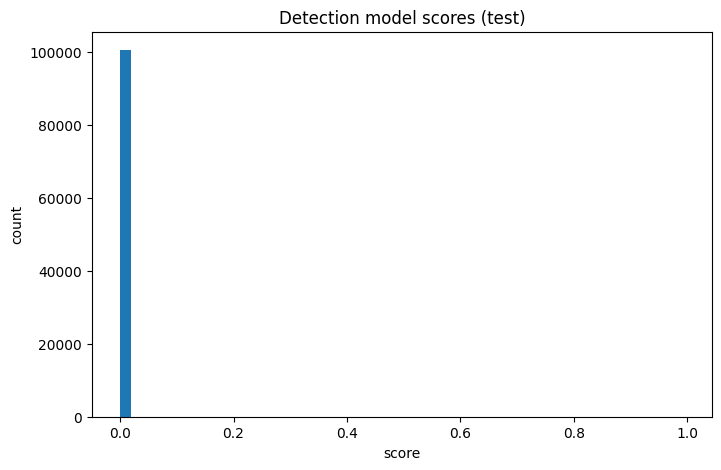

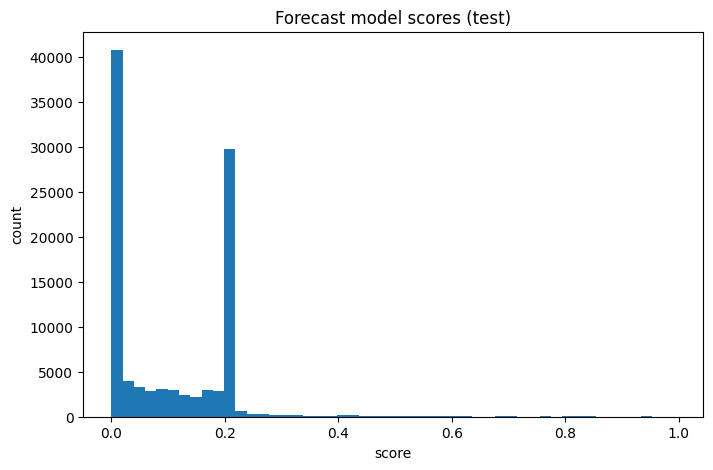

In [6]:
# %%
plot_hist(yd_test_scores, "Detection model scores (test)", "score")
plot_hist(yf_test_scores, "Forecast model scores (test)", "score")


 ## 6. Feature Layout and Name Decoding



 We trained on 14-day windows with per-day base features.

 `feature_spec.json` contains the **base feature names** (per day). XGBoost sees a flattened

 vector of length:



 `n_total = n_days * n_base`



 and automatically names them `f0, f1, ..., f{n_total-1}` (0-based).



 We decode `f123` as:



 ```text

 idx      = 123

 day_idx  = idx // n_base

 base_idx = idx %  n_base

 base_name = base_features[base_idx]

 pretty   = f"day{day_idx}_{base_name}"

 ```

In [7]:
# %%
spec_path = ML_DETECT / "feature_spec.json"
with spec_path.open("r") as f:
    spec = json.load(f)

base_features = spec["features"]
n_base = len(base_features)
n_total = detect_np["X_train"].shape[1]
n_days = n_total // n_base

print("Base features:", n_base)
print("Total features:", n_total)
print("Days in window:", n_days)
# Build human-readable names for *every* column in the flattened window
# index -> "day{day_idx}_{base_name}"
all_feature_names = []
for idx in range(n_total):
    day_idx = idx // n_base
    base_idx = idx % n_base
    base_name = base_features[base_idx]
    all_feature_names.append(f"day{day_idx}_{base_name}")

print("Example feature names:", all_feature_names[:10])
print("Total names:", len(all_feature_names))


def decode_feature_name(f_name: str):
    """Convert 'f123' into (pretty_name, day_idx, base_name).

    XGBoost uses 0-based indexing: f0..f{n_features-1}.
    """
    idx = int(f_name[1:])  # 'f123' -> 123
    day_idx = idx // n_base
    base_idx = idx % n_base
    base_name = base_features[base_idx]
    pretty = f"day{day_idx}_{base_name}"
    return pretty, day_idx, base_name


def decode_importance(imp_list):
    """Convert [(f105, val), ...] into decoded dicts with human-readable names."""
    decoded = []
    for f_name, val in imp_list:
        pretty, day_idx, base_name = decode_feature_name(f_name)
        decoded.append(
            {
                "xgb_name": f_name,
                "pretty_name": pretty,
                "day_idx": day_idx,
                "base_name": base_name,
                "importance": float(val),
            }
        )
    return decoded


def aggregate_by_base(decoded_imp):
    """Aggregate importance over all days for each base feature."""
    agg = {}
    for row in decoded_imp:
        base = row["base_name"]
        agg[base] = agg.get(base, 0.0) + row["importance"]
    return sorted(agg.items(), key=lambda kv: kv[1], reverse=True)


Base features: 24
Total features: 336
Days in window: 14
Example feature names: ['day0_logon_after_hours_rate', 'day0_logon_on_shared_pc_rate', 'day0_logon_on_unassigned_pc_rate', 'day0_device_n_usb_connects', 'day0_device_n_usb_disconnects', 'day0_device_after_hours_rate', 'day0_device_usb_on_shared_pc_rate', 'day0_file_n_to_removable', 'day0_file_n_from_removable', 'day0_file_after_hours_rate']
Total names: 336


 ## 7. Global Feature Importance (Gain, Cover, Weight)

In [8]:
# %%
detect_booster = detect_model.get_booster()
forecast_booster = forecast_model.get_booster()

# Gain: main view
det_gain_raw = get_feature_importance(detect_booster, importance_type="gain")[:50]
for_gain_raw = get_feature_importance(forecast_booster, importance_type="gain")[:50]

det_gain_decoded = decode_importance(det_gain_raw)
for_gain_decoded = decode_importance(for_gain_raw)

print("\nTop 20 features by gain – Detection model (per day):\n")
for row in det_gain_decoded[:20]:
    print(f"{row['pretty_name']}\t{row['importance']:.4f}")

print("\nTop 20 features by gain – Forecast model (per day):\n")
for row in for_gain_decoded[:20]:
    print(f"{row['pretty_name']}\t{row['importance']:.4f}")

# Aggregate to base feature level
det_gain_base = aggregate_by_base(det_gain_decoded)
for_gain_base = aggregate_by_base(for_gain_decoded)

print("\nTop 15 base features by total gain – Detection model:\n")
for name, val in det_gain_base[:15]:
    print(f"{name}\t{val:.4f}")

print("\nTop 15 base features by total gain – Forecast model:\n")
for name, val in for_gain_base[:15]:
    print(f"{name}\t{val:.4f}")



Top 20 features by gain – Detection model (per day):

day4_file_after_hours_rate	198.7109
day4_ah_rate_baseline	181.3743
day13_device_after_hours_rate	180.7259
day11_usb_count_baseline	148.5503
day13_file_after_hours_rate	111.4835
day12_usb_novel	96.1252
day9_usb_count_baseline	83.6415
day0_usb_count_baseline	69.5894
day1_file_n_from_removable	69.2685
day11_usb_novel	61.6958
day13_usb_novel	54.9722
day12_file_after_hours_rate	49.1343
day12_device_after_hours_rate	34.1601
day13_file_n_to_removable	32.7419
day3_usb_count_trend	26.6416
day2_file_after_hours_rate	24.4767
day11_file_after_hours_rate	19.3017
day13_file_n_from_removable	16.0182
day10_usb_count_baseline	14.3471
day9_usb_novel	14.1320

Top 20 features by gain – Forecast model (per day):

day13_usb_novel	15359.7715
day1_ah_rate_trend	8594.5762
day4_email_after_hours_rate	8303.9434
day0_usb_count_baseline	6836.8833
day8_ah_rate_1d	6292.4507
day2_ah_rate_trend	6231.3579
day5_email_after_hours_rate	5616.4463
day4_http_after_hours_

In [9]:
# %%
# Optional: cover / weight in the same human-readable way
for imp_type in ["cover", "weight"]:
    print(f"\n===== {imp_type.upper()} importance (top 10 per-day features) =====\n")

    det_imp = get_feature_importance(detect_booster, importance_type=imp_type)[:10]
    for_imp = get_feature_importance(forecast_booster, importance_type=imp_type)[:10]

    det_dec = decode_importance(det_imp)
    for_dec = decode_importance(for_imp)

    print("\nDetection:")
    for row in det_dec:
        print(f"{row['pretty_name']}\t{row['importance']:.4f}")

    print("\nForecast:")
    for row in for_dec:
        print(f"{row['pretty_name']}\t{row['importance']:.4f}")



===== COVER importance (top 10 per-day features) =====


Detection:
day9_http_n_dropbox	50.8963
day7_device_after_hours_rate	50.0655
day12_file_after_hours_rate	42.1996
day6_ah_rate_1d	36.9677
day13_usb_novel	34.0079
day12_usb_novel	32.3713
day9_usb_novel	30.9205
day10_file_after_hours_rate	28.4161
day11_usb_novel	28.0640
day10_usb_novel	27.7056

Forecast:
day0_usb_count_baseline	79572.1484
day11_email_after_hours_rate	68710.4688
day9_http_after_hours_rate	61708.6484
day8_ah_rate_1d	59230.8711
day11_ah_rate_1d	54124.5273
day13_email_after_hours_rate	52289.4844
day9_email_after_hours_rate	51311.3008
day13_usb_novel	50725.1680
day6_http_n_dropbox	49437.1562
day1_logon_after_hours_rate	47418.3125

===== WEIGHT importance (top 10 per-day features) =====


Detection:
day13_ah_rate_1d	70.0000
day13_ah_rate_trend	55.0000
day13_usb_count_trend	52.0000
day4_ah_rate_trend	45.0000
day13_http_n_wikileaks	42.0000
day9_ah_rate_trend	41.0000
day10_ah_rate_trend	40.0000
day11_ah_rate_trend	33.0000
da

 ## 8. SHAP Explanations (Optional)

Building SHAP TreeExplainer for detection model...
Building SHAP TreeExplainer for forecast model...
Detection model SHAP summary (test subset):


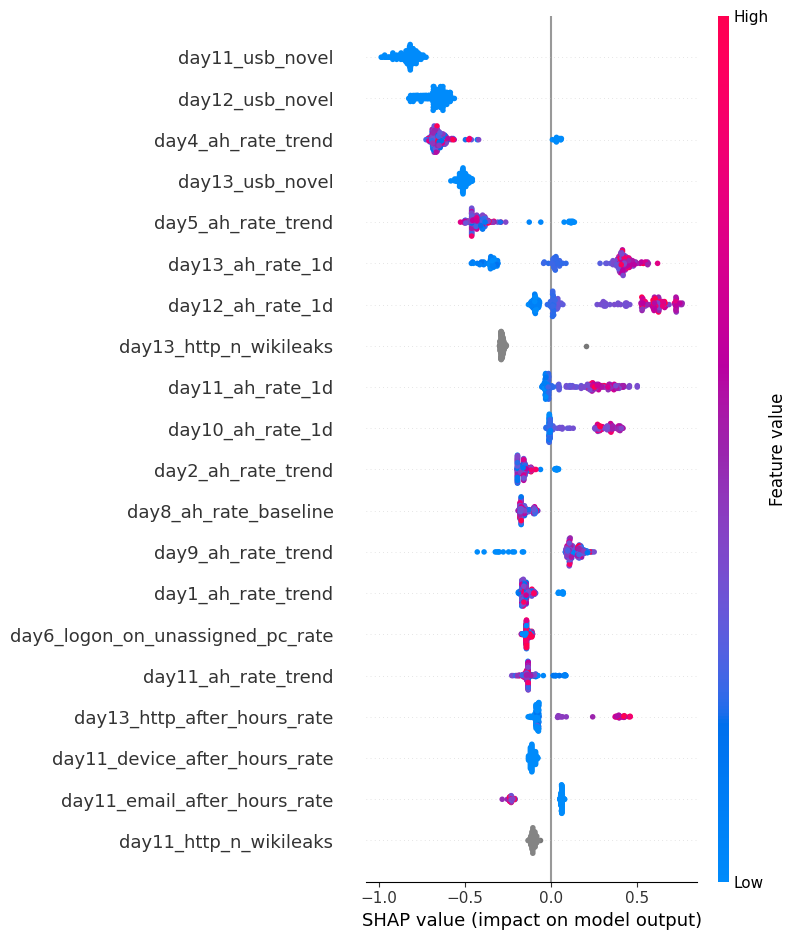

Forecast model SHAP summary (test subset):


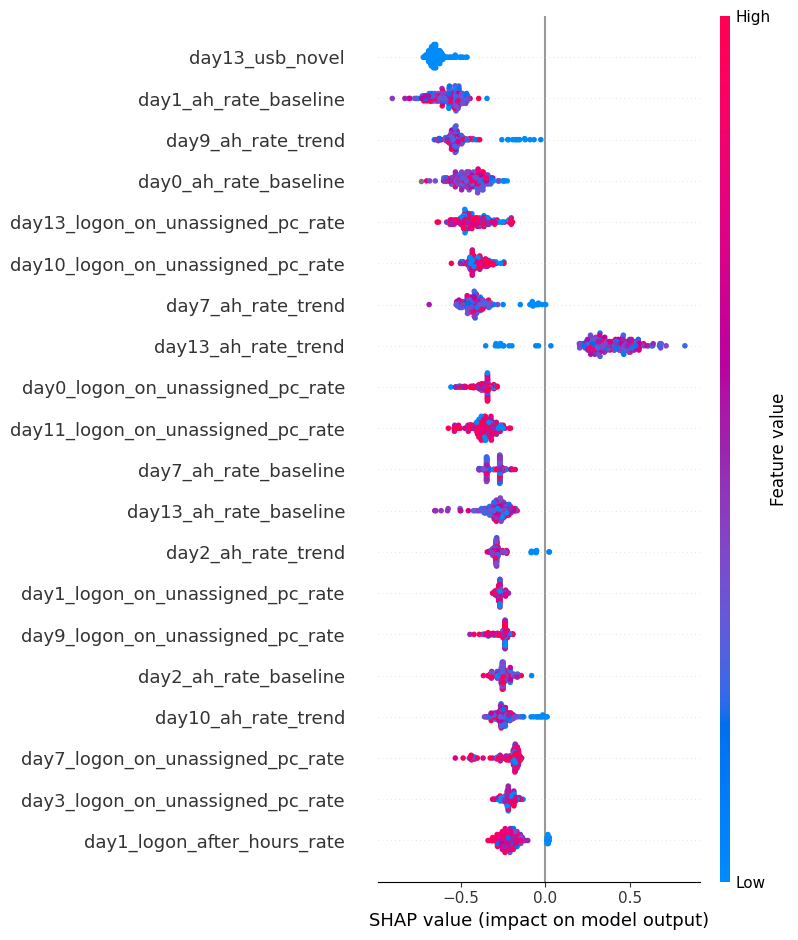

In [10]:
# %%
if shap is None:
    print("SHAP is not installed; run `pip install shap` to enable this section.")
else:
    n_sample = min(200, len(Xd_test))
    Xd_test_sub = Xd_test[:n_sample]
    Xf_test_sub = Xf_test[:n_sample]

    # Wrap in DataFrames so SHAP uses our column names
    Xd_df = pd.DataFrame(Xd_test_sub, columns=all_feature_names)
    Xf_df = pd.DataFrame(Xf_test_sub, columns=all_feature_names)

    print("Building SHAP TreeExplainer for detection model...")
    explainer_detect = shap.TreeExplainer(detect_model)
    shap_vals_detect = explainer_detect.shap_values(Xd_df)

    print("Building SHAP TreeExplainer for forecast model...")
    explainer_forecast = shap.TreeExplainer(forecast_model)
    shap_vals_forecast = explainer_forecast.shap_values(Xf_df)

    print("Detection model SHAP summary (test subset):")
    shap.summary_plot(shap_vals_detect, Xd_df, show=False)
    plt.show()

    print("Forecast model SHAP summary (test subset):")
    shap.summary_plot(shap_vals_forecast, Xf_df, show=False)
    plt.show()


 ## 9. Leaf Index Fingerprints

In [11]:
# %%
d_dmat = xgb.DMatrix(Xd_test)
detect_leaf_index = detect_model.get_booster().predict(d_dmat, pred_leaf=True)

f_dmat = xgb.DMatrix(Xf_test)
forecast_leaf_index = forecast_model.get_booster().predict(f_dmat, pred_leaf=True)

print("Detection leaf index shape:", detect_leaf_index.shape)
print("Forecast  leaf index shape:", forecast_leaf_index.shape)


def count_unique_rows(arr, n_sample=1000):
    arr_sub = arr[: min(n_sample, len(arr))]
    rows = [tuple(row) for row in arr_sub]
    return len(set(rows)), len(rows)


n_unique_det, n_rows_det = count_unique_rows(detect_leaf_index)
n_unique_for, n_rows_for = count_unique_rows(forecast_leaf_index)

print(f"Detection: {n_unique_det} unique leaf patterns out of {n_rows_det} samples (subset)")
print(f"Forecast:  {n_unique_for} unique leaf patterns out of {n_rows_for} samples (subset)")


Detection leaf index shape: (100612, 300)
Forecast  leaf index shape: (100590, 300)
Detection: 686 unique leaf patterns out of 1000 samples (subset)
Forecast:  696 unique leaf patterns out of 1000 samples (subset)


 ## 10. Hyperparameter Audit

In [12]:
# %%
print("Detection model hyperparameters:\n")
print(detect_model.get_xgb_params())

print("\nForecast model hyperparameters:\n")
print(forecast_model.get_xgb_params())


Detection model hyperparameters:

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'eval_metric': 'logloss', 'gamma': None, 'grow_policy': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'monotone_constraints': None, 'multi_strategy': None, 'n_jobs': 4, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}

Forecast model hyperparameters:

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'eval_metric': 'aucpr', 'gamma': N

 ## 11. Interpreting Results and Next ML Steps



 Things to pay attention to when you run this:



 1. **Metrics**

    - Is the forecast model clearly weaker than detection?

    - Any big train vs val/test gap (overfitting)?



 2. **Per-day features**

    - Are late-window days dominating (e.g., `day12_`, `day13_`)?



 3. **Base features**

    - After aggregating over days, which signals really matter?

    - Do they line up with the Scenario-1 story (after-hours, USB, risky web)?



 4. **SHAP (if enabled)**

    - For high-score windows, which features consistently push scores up?



 5. **Leaf patterns**

    - Does the forecast model show multiple distinct “pre-exfil regimes”?



 Use this to decide what to tweak next: features, label definition, or model regularization.